## Introduction

The objective is **to evaluate how the urban mobility is related with the economic productivity in latin america principal cities.** For this, I will work with real data of TomTom Traffic Index and OECD Citities, so I can clean, combine and analyze to identify in which cities is better to invest in transportation infraestructure.  

## 🧩 Step 1: Load and Explore

Validate that the files are loadly correctly, review their columns and data types, and identify potential inconsistencies.

### 1.1 Data Loading and Quick Overview

**🎯Objective:**
Import the required libraries, load the CSV files into DataFrames, and perform an initial review to understand their structure and content.


In [ ]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load files
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# Look the first 5 rows of Traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# Look the first 5 rows of eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Step 2: Explore, Clean, and Prepare the Data

Inspect the dataset structure, data types, columns, and missing values.

### 2.1 Explore Structure and Data Types

**🎯Objective:**
Identify columns with incorrect data types, analyze distributions and missing values, and note the columns that require conversion.



In [ ]:
# Examine traffic structure
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In the structure of the traffic DataFrame, the following observations were identified:

- The `UpdateTimeUTC` and `UpdateTimeUTCWeekAgo` columns are currently stored as object type and should be converted to DateTime format. These columns require data type conversion.

- The `JamsCount` column should be converted from float to integer type.

- The traffic DataFrame contains 1,004,464 rows, and none of its columns contain missing values.

In [ ]:
# Examine Eco structure
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


In the structure of the Eco DataFrame, the following observations were identified:

- The columns `City GDP/capita`, `Unemployment %`, `PM2.5(μg/m³)` and `Population (M)`should be converted from object to float type.
- The Eco DataFrame contains 30 rows, and none of its columns contain missing values.

### 2.2 Columns Rename

**🎯Objective:**
Standardize column names to prevent errors and facilitate dataset merging.


In [ ]:
# Standarize column names of traffic.
traffic=traffic.rename(columns={'Country':'country', \
                                'City':'city',\
                               'UpdateTimeUTC':'update_time_utc',\
                               'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',\
                               'JamsDelay':'jams_delay',\
                               'TrafficIndexLive':'traffic_index_live',\
                               'JamsLengthInKms':'jams_length_kms',\
                               'JamsCount':'jams_count',\
                               'TrafficIndexWeekAgo':'traffic_index_week_ago',\
                                'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins',\
                                'TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins',\
                               'MinsDelay':'mins_delay'}
                                )

# validate changes
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Standarize column names of eco
eco=eco.rename(columns={'Year':'year',\
                        'City':'city',\
                        'Country':'country',\
                       'City GDP/capita':'city_gdp_capita',\
                       'Unemployment %':'unemployment_pct',\
                       'PM2.5 (μg/m³)':'pm25',\
                       'Population (M)':'population_m'})

# validate changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Correct numeric and date formats

**🎯Objective:**
Ensure that date and numerical value columns are in the correct formats to enable accurate analysis, calculations, and comparisons.





In [ ]:
# Convert the columns of traffic a date type.
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors="coerce")

# verify change
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
# Clean separators and convert numeric columns in the eco dataset.
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calculate total population in absolute units. (Multiply * 1000000)
eco['population'] = eco['population_m'] * 1000000

# Verify change
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Step 3:Extract year and filter data.

Extracting the year allows to filter the information and work only with the most recent and relevant period.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objective**
Identify the year of each record and retain only records from 2024.


In [ ]:
# Extracting the year of dates in update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verify change
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtering records from 2024.
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Review new dataframes
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Step 4: Analyze and summarize mobility data

Since the traffic dataset contains **multiple records per city**, annual city-level averages will be calculated to simplify the analysis and provide a clearer view of overall trends.



### 4.1 Calculate averages of traffic by city.

**🎯Objective:**
Obtain a consolidated view of average traffic by city and year in order to analyze general patterns without relying on daily-level data.



In [ ]:
# Calculating the averages of traffic by city, country and year
group_cols=['city','country','year']
traffic_city_year_2024 =  traffic_2024.groupby(group_cols, dropna=False)\
                                        .agg({'jams_delay':'mean',\
                                            'traffic_index_live':'mean',\
                                            'jams_length_kms':'mean',\
                                            'jams_count':'mean',\
                                            'mins_delay':'mean',\
                                            'travel_time_live_per_10kms_mins' : 'mean',\
                                            'travel_time_hist_per_10kms_mins':'mean'})\
                                        .reset_index()

# Show result
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


The city with the most average traffic time is Mexico City


---

## 🧩Step 5: Merge mobility and economy

Merging datasets allows to analyze how economic indicators relate to mobility indicators.

### 5.1 Merge traffic (principal table) with economic indicators

**🎯Objective:**
Merge traffic and economic data into a single DataFrame to analyze how economic conditions are associated with urban mobility.



In [ ]:
# Selecting key columns of traffic and economy.
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Using .copy() to create the two reduced datasets.
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Merging datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Showing the first 5 rows
merged.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Step 6: Data visualization and relationship analysis

### 6.1 Visualize relationship between economic and traffic indicators.

**🎯Objective:**
Visually analyze the distribution and relationship between traffic and economic indicators in 2024 in order to identify potential patterns or overall trends between both variables.


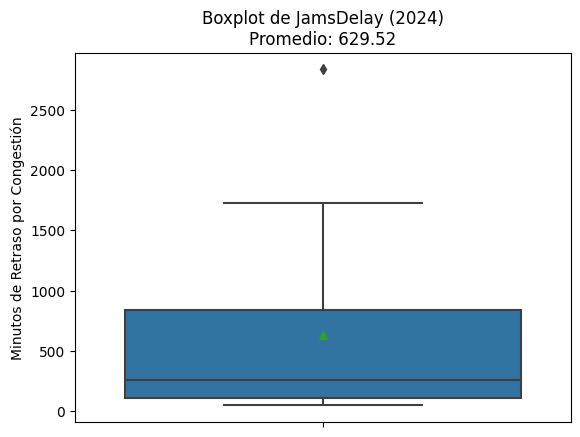

In [ ]:
# Creating a boxplot to observe the behavior of JamsDelay minutes congestion.
sns.boxplot(data=merged, y="jams_delay", showmeans=True)

# Obtaining average to show it on the title.
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Minutos de Retraso por Congestión')
plt.xlabel('')
plt.show()


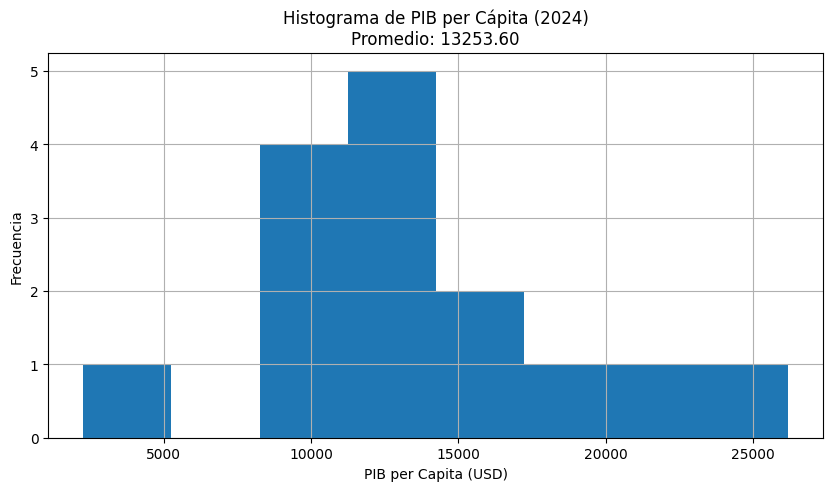

In [ ]:
# Creating histogram to observe the distribution of economy (city_gdp_capita)
merged['city_gdp_capita'].hist(bins=8, figsize=(10,5))
# Obtaining average to show it on the title.
mean_gdp = merged['city_gdp_capita'].mean()
plt.title(f'Histogram of PIB per Cápita (2024)\nPromedio: {mean_gdp:.2f}')
plt.ylabel('Frecuencia')
plt.xlabel('PIB per Capita (USD)')
plt.show()


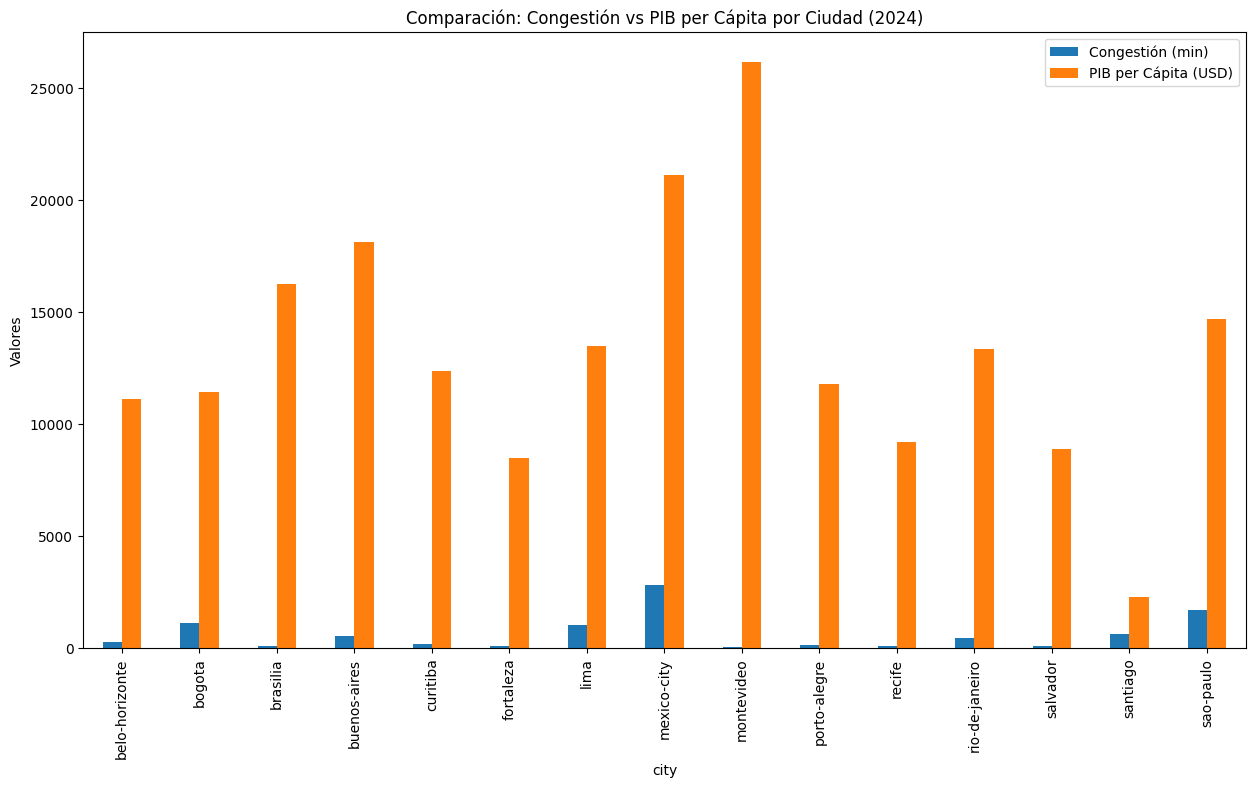

In [ ]:
# Bar graph to compare jams_delay and city_gdp_capita by city.
merged.plot(kind="bar", x='city', y=['jams_delay', 'city_gdp_capita'], figsize=(15,8))
plt.title('Comparación: Congestión vs PIB per Cápita por Ciudad (2024)')
plt.ylabel('Valores')
plt.xticks(rotation=90)
plt.legend(['Congestión (min)', 'PIB per Cápita (USD)'])
plt.show()

**Comments:** In the comparison chart between GDP per capita and congestion minutes, there is no clear direct or inverse relationship between the two variables. For example, Montevideo has a high GDP per capita with very low congestion levels, while Mexico City also has a high GDP per capita but exhibits the highest congestion among the analyzed cities.


---

## 🧩Step 7: Export and document results

### 7.1 Save final dataset

**🎯Objective:**
Generate a clean, reproducible CSV file containing relevant columns for further analysis.

In [ ]:
# Export final dataset as CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Ejecutive Summary

**Context & Objective**

The first step of the analysis was to evaluate whether a relationship exists between urban mobility and economic productivity. Based on the generated visualizations, traffic congestion and GDP per capita do not show a clear relationship.

In this case study, the key variables are `city` and `year`, which define the analysis scope by specific cities and years. Additional key variables include `mins_delay` (representing the average delay in minutes per 10 km caused by congestion) and `city_gdp_capita` (GDP per capita), which help determine whether there is a relationship between urban mobility and economic productivity, supporting investment decision-making for specific cities.

The key variables included in the final DataFrame are: `city`, `country`, `year`, `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, `travel_time_live_per_10kms_mins`, `travel_time_hist_per_10kms_mins`, `city_gdp_capita`, `unemployment_pct`, `pm25`, and `population`.

---

**Data Coverage**

The analysis was limited to the year 2024 and included 15 cities across the following countries: Brazil, Colombia, Argentina, Peru, Mexico, Uruguay, and Chile.

---

**Methodology**

First, the datasets from each source were explored individually. During the data cleaning process, it was identified that the `UpdateTimeUTC` and `UpdateTimeUTCWeekAgo` columns were stored as `object` type and needed conversion to `DateTime` format. These columns were converted accordingly. The `JamsCount` column was also converted from `float` to `integer`.

The DataFrames were evaluated to confirm the absence of missing values, and column names were standardized into `snake_case` format. Data types were corrected to numeric and datetime formats where appropriate.

The merge was performed using `city` and `year` as join keys, since both variables were available in the economic (`eco`) and traffic (`traffic`) DataFrames. An `INNER JOIN` was selected because the analysis only required cities present in both datasets. The resulting merged DataFrame combined relevant traffic and economic variables and was prepared for further analysis.

Three visual validation methods were applied:

1. **Boxplot:** Used to observe the mean, median, and detect outliers in `jams_delay`. An extreme outlier above 2,500 congestion delay minutes was identified.

2. **Histogram:** Used to visualize the distribution of GDP per capita in USD across the analyzed cities, as well as the average GDP level.

3. **Bar Chart:** Used to compare and observe the relationship between GDP per capita and congestion delay time.

---

**Initial Findings**

No clear linear relationship exists between GDP per capita and traffic congestion. Cities with high GDP per capita can exhibit either low congestion levels (Montevideo) or extremely high congestion levels (Mexico City).

Several extreme cases were identified:

### 1. Mexico City

* Congestion: 2,833 minutes of delay (extremely high)
* GDP per capita: approximately $15,000 (relatively high)

### 2. Montevideo

* Congestion: very low
* GDP per capita: approximately $18,000 (the highest among analyzed cities)

### 3. Bogotá

* Congestion: 1,141 minutes (second highest)
* GDP per capita: approximately $11,000 (moderate)

GDP per capita varies significantly across Latin American cities, while congestion levels do not follow a predictable pattern based solely on economic performance.

---

## Recommendations

Based on the analysis, Bogotá is identified as a priority city for transportation investment due to its high congestion levels, moderate economic productivity indicators, and the potential positive impact on a large population.

### Additional Recommended Analyses

1. Population density vs. congestion
2. Public transportation investment by city
3. Temporal analysis: Are these trends consistent over time?
